In [1]:
import pandas as pd

file = 'options_data_2025&2026.xlsx'

xl = pd.ExcelFile(file)
print(f"Sheets found: {xl.sheet_names}\n")

for sheet in xl.sheet_names:
    df = pd.read_excel(file, sheet_name=sheet, nrows=0)  # header only
    print(f"── Sheet: '{sheet}'")
    print(f"   Columns ({len(df.columns)}): {list(df.columns)}")
    print()


Sheets found: ['ExpiryTable', 'Call', 'Put', 'IV', 'Straddle', 'Delta_interpolation', 'Delta_Trading', 'Pnl_interpolation', 'Pnl_Trading']

── Sheet: 'ExpiryTable'
   Columns (2): ['Month', 'Expiry']

── Sheet: 'Call'
   Columns (33): ['Date', 'Underlying (SPX Spot)', 'ATM Strike', 'FrontExp', 'NextExp', 'TargetDTE', 'DTE_F = FrontExp - Date', 'DTE_N = NextExp - Date', 'Weighted_Front', 'Weighted_N', 'Check', 'Front Call Ticker', 'Last', 'Bid', 'Ask', 'Mid=(Bid+Ask)/2', 'Delta', 'IV', 'Next Call Ticker', 'Last.1', 'Bid.1', 'Ask.1', 'Mid=(Bid+Ask)/2.1', 'Delta.1', 'IV.1', 'IV_30D', 'IV_30D(call+put)/2', 'RF_1M', 'RF_1M/100', 'T(30/365)', 'Call delta', 'Put delta', 'Straddle delta']

── Sheet: 'Put'
   Columns (27): ['Date', 'Underlying (SPX Spot)', 'ATM Strike', 'FrontExp', 'NextExp', 'TargetDTE', 'DTE_F = FrontExp - Date', 'DTE_N = NextExp - Date', 'Weighted_Front', 'Weighted_N', 'Check', 'Front Call Ticker', 'Last', 'Bid', 'Ask', 'Mid=(Bid+Ask)/2', 'Delta', 'IV', 'Next Call Ticker', '

── LOADING DATA ──
✓ Data loaded
✓ EWMA 30-Day Forecast calculated
  Lambda (λ) used: 0.9355
✓ Merged rows : 250
✓ Filtered to Jul 2025 – Apr 2026 : 128 rows (2025-07-01 → 2025-12-31)
✓ Black-Scholes deltas calculated

✓ Data-driven thresholds calculated from vol_spread distribution:
  Upper threshold (75th pct) : 0.0332
  Lower threshold (25th pct) : 0.0077
  Spread mean                : 0.0206
  Spread std                 : 0.0179

✓ Signals generated:
  {'HOLD/NONE': 12, 'LONG_STRADDLE': 7, 'SHORT_STRADDLE': 7}
✓ Delta hedging calculated
✓ Trades captured : 13

══ FULL BACKTEST RESULTS ══
Entry Date  Exit Date         Signal  Entry Price  Exit Price  Straddle PnL  Hedge PnL     Cost    Net PnL  Cumulative PnL
2025-07-01 2025-07-08  LONG_STRADDLE   188.457143  191.621429      3.164286  -1.998678 0.380079   0.785529        0.785529
2025-07-09 2025-07-15  LONG_STRADDLE   181.900000  201.898214     19.998214   1.782408 0.383798  21.396824       22.182353
2025-08-13 2025-08-19  LONG_STRA

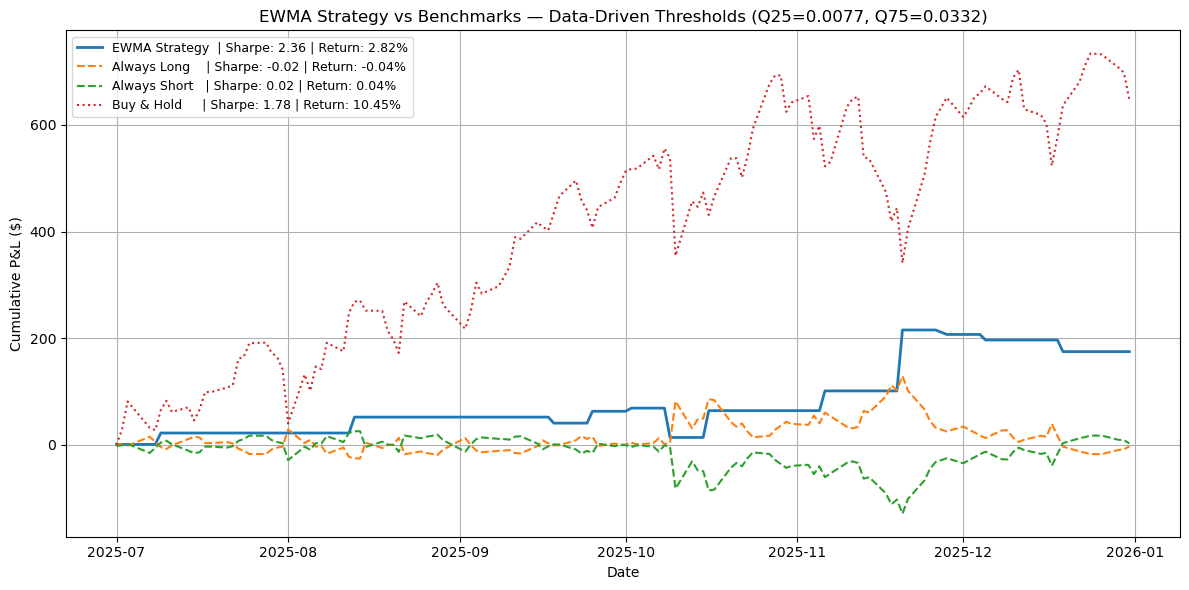

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# SETTINGS
# ══════════════════════════════════════════════════════════════════════════════
SPAN         = 30
CYCLE_LENGTH = 5
TRANS_COST   = 0.001
IV_COL       = 'IV_30D=(B2+C2)/2'
STRADDLE_COL = '30D Constant-Maturity Straddle'
EXCEL_FILE   = 'options_data_2025&2026.xlsx'

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════════
print("── LOADING DATA ──")
df_25       = pd.read_csv('SPY_Close_modeling_2.5y.csv')
df_05       = pd.read_csv('SPY_Close_forecast_0.5y.csv')
iv_df       = pd.read_excel(EXCEL_FILE, sheet_name='IV')
delta_df    = pd.read_excel(EXCEL_FILE, sheet_name='Delta_Trading')
straddle_df = pd.read_excel(EXCEL_FILE, sheet_name='Straddle')

df = pd.concat([df_25, df_05], axis=0).reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

iv_df['Date']       = pd.to_datetime(iv_df['Date'])
delta_df['Date']    = pd.to_datetime(delta_df['Date'])
straddle_df['Date'] = pd.to_datetime(straddle_df['Date'])
print("✓ Data loaded")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — EWMA VOLATILITY (30-DAY FORECAST)
# ══════════════════════════════════════════════════════════════════════════════
def get_ewma_forecast(df, col_name, span=30):
    TRADING_DAYS = 252
    sq_returns     = df[col_name] ** 2
    daily_var_ewma = sq_returns.ewm(span=span, adjust=False).mean()
    annual_vol     = np.sqrt(daily_var_ewma * TRADING_DAYS)
    return annual_vol

df['forecast_vol'] = get_ewma_forecast(df, col_name='log_return', span=SPAN)
print(f"✓ EWMA 30-Day Forecast calculated")
print(f"  Lambda (λ) used: {1 - (2 / (SPAN + 1)):.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — MERGE ALL DATA
# ══════════════════════════════════════════════════════════════════════════════
merged_df = pd.merge(iv_df, df[['Date', 'close', 'forecast_vol']], on='Date', how='inner')

merged_df = pd.merge(
    merged_df,
    delta_df[['Date', 'Underlying (SPX Spot)', 'ATM Strike',
              'RF_1M/100', 'DTE_F = FrontExp - Date',
              'Call Delta（Trading）', 'Put Delta (Trading)',
              'Straddle Delta']],
    on='Date', how='inner'
)

merged_df = pd.merge(
    merged_df,
    straddle_df[['Date', STRADDLE_COL, 'PnL', 'Return']],
    on='Date', how='inner'
)
merged_df = merged_df.reset_index(drop=True)
print(f"✓ Merged rows : {len(merged_df)}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3b — FILTER TO TRADING PERIOD (Jul 1 2025 – Apr 15 2026)
# ══════════════════════════════════════════════════════════════════════════════
merged_df = merged_df[
    (merged_df['Date'] >= '2025-07-01') &
    (merged_df['Date'] <= '2026-04-15')
].reset_index(drop=True)

print(f"✓ Filtered to Jul 2025 – Apr 2026 : {len(merged_df)} rows "
      f"({merged_df['Date'].min().date()} → {merged_df['Date'].max().date()})")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — BLACK-SCHOLES DELTAS
# ══════════════════════════════════════════════════════════════════════════════
def calculate_bs_deltas(row):
    S          = row['Underlying (SPX Spot)']
    K          = row['ATM Strike']
    r          = row['RF_1M/100']
    T          = row['DTE_F = FrontExp - Date'] / 365
    sigma_call = row['IV_30D_Call(%)'] / 100
    sigma_put  = row['IV_30D_Put(%)']  / 100

    d1_call    = (np.log(S / K) + (r + 0.5 * sigma_call ** 2) * T) / (sigma_call * np.sqrt(T))
    delta_call = norm.cdf(d1_call)

    d1_put     = (np.log(S / K) + (r + 0.5 * sigma_put ** 2) * T) / (sigma_put * np.sqrt(T))
    delta_put  = norm.cdf(d1_put) - 1

    return pd.Series([delta_call, delta_put, delta_call + delta_put])

merged_df[['BS_Call_Delta', 'BS_Put_Delta', 'BS_Straddle_Delta']] = merged_df.apply(
    calculate_bs_deltas, axis=1
)
print("✓ Black-Scholes deltas calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — VOL SPREAD + DATA-DRIVEN THRESHOLDS
# ══════════════════════════════════════════════════════════════════════════════
merged_df['vol_spread'] = merged_df[IV_COL] - merged_df['forecast_vol']

UPPER_THRESH = merged_df['vol_spread'].quantile(0.75)
LOWER_THRESH = merged_df['vol_spread'].quantile(0.25)

print(f"\n✓ Data-driven thresholds calculated from vol_spread distribution:")
print(f"  Upper threshold (75th pct) : {UPPER_THRESH:.4f}")
print(f"  Lower threshold (25th pct) : {LOWER_THRESH:.4f}")
print(f"  Spread mean                : {merged_df['vol_spread'].mean():.4f}")
print(f"  Spread std                 : {merged_df['vol_spread'].std():.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — SIGNALS
# ══════════════════════════════════════════════════════════════════════════════
merged_df['cycle_day']    = (np.arange(len(merged_df)) % CYCLE_LENGTH) + 1
merged_df['entry_signal'] = 'HOLD/NONE'

day_1_mask = (merged_df['cycle_day'] == 1)
merged_df.loc[day_1_mask & (merged_df['vol_spread'] > UPPER_THRESH), 'entry_signal'] = 'SHORT_STRADDLE'
merged_df.loc[day_1_mask & (merged_df['vol_spread'] < LOWER_THRESH), 'entry_signal'] = 'LONG_STRADDLE'

print(f"\n✓ Signals generated:")
print(f"  {merged_df[day_1_mask]['entry_signal'].value_counts().to_dict()}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — DELTA HEDGING
# ══════════════════════════════════════════════════════════════════════════════
merged_df['Straddle_Delta_Trading'] = (
    merged_df['Call Delta（Trading）'] + merged_df['Put Delta (Trading)']
)
merged_df['active_pos'] = merged_df['entry_signal'].replace('HOLD/NONE', np.nan).ffill()

def calculate_share_hedge(row):
    if row['cycle_day'] == 5:                  return 0
    if row['active_pos'] == 'LONG_STRADDLE':   return -row['Straddle_Delta_Trading']
    if row['active_pos'] == 'SHORT_STRADDLE':  return  row['Straddle_Delta_Trading']
    return 0

merged_df['share_hedge_qty']   = merged_df.apply(calculate_share_hedge, axis=1)
merged_df['daily_hedge_trade'] = merged_df['share_hedge_qty'].diff().fillna(0)
merged_df.loc[merged_df['cycle_day'] == 1, 'daily_hedge_trade'] = merged_df['share_hedge_qty']
print("✓ Delta hedging calculated")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — BACKTEST P&L
# ══════════════════════════════════════════════════════════════════════════════
results = []

for i in range(len(merged_df)):
    row    = merged_df.iloc[i]
    signal = row['entry_signal']

    if row['cycle_day'] != 1 or signal == 'HOLD/NONE':
        continue

    exit_idx = i + 4
    if exit_idx >= len(merged_df):
        continue

    exit_row    = merged_df.iloc[exit_idx]
    entry_price = row[STRADDLE_COL]
    exit_price  = exit_row[STRADDLE_COL]

    if signal == 'SHORT_STRADDLE':
        straddle_pnl = entry_price - exit_price
    else:
        straddle_pnl = exit_price - entry_price

    hedge_pnl = 0
    for d in range(i, min(i + 5, len(merged_df) - 1)):
        hedge_row    = merged_df.iloc[d]
        next_row     = merged_df.iloc[d + 1]
        price_change = (next_row['Underlying (SPX Spot)']
                      - hedge_row['Underlying (SPX Spot)'])
        hedge_pnl   += hedge_row['share_hedge_qty'] * price_change

    cost    = (entry_price + exit_price) * TRANS_COST
    net_pnl = straddle_pnl + hedge_pnl - cost

    results.append({
        'Entry Date'   : row['Date'],
        'Exit Date'    : exit_row['Date'],
        'Signal'       : signal,
        'Entry Price'  : entry_price,
        'Exit Price'   : exit_price,
        'Straddle PnL' : straddle_pnl,
        'Hedge PnL'    : hedge_pnl,
        'Cost'         : cost,
        'Net PnL'      : net_pnl
    })

results_df = pd.DataFrame(results)
results_df['Cumulative PnL'] = results_df['Net PnL'].cumsum()
print(f"✓ Trades captured : {len(results_df)}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — PERFORMANCE METRICS
# ══════════════════════════════════════════════════════════════════════════════
wins     = results_df[results_df['Net PnL'] > 0].shape[0]
total    = results_df.shape[0]
win_rate = wins / total if total > 0 else 0
sharpe   = results_df['Net PnL'].mean() / results_df['Net PnL'].std() * np.sqrt(52)
max_dd   = (results_df['Cumulative PnL'] - results_df['Cumulative PnL'].cummax()).min()

print("\n══ FULL BACKTEST RESULTS ══")
print(results_df.to_string(index=False))

print("\n══ PERFORMANCE METRICS ══")
print(f"  Total Trades   : {total}")
print(f"  Win Rate       : {win_rate:.1%}")
print(f"  Sharpe Ratio   : {sharpe:.2f}")
print(f"  Max Drawdown   : ${max_dd:.2f}")
print(f"  Final Cum. PnL : ${results_df['Cumulative PnL'].iloc[-1]:.2f}")

print("\n══ SIGNAL BREAKDOWN ══")
print(results_df.groupby('Signal')['Net PnL'].agg(['sum', 'mean', 'count']).to_string())

# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — BENCHMARK COMPARISON + PLOT
# ══════════════════════════════════════════════════════════════════════════════
merged_df['cum_always_long']  = merged_df['PnL'].cumsum()
merged_df['cum_always_short'] = (-merged_df['PnL']).cumsum()
merged_df['cum_buy_hold']     = merged_df['Underlying (SPX Spot)'].diff().fillna(0).cumsum()
merged_df['cum_strategy_pnl'] = (
    merged_df['Date']
    .map(results_df.set_index('Entry Date')['Cumulative PnL'])
    .ffill()
    .fillna(0)
)

def calc_sharpe(pnl_series, periods=252):
    mean, std = pnl_series.mean(), pnl_series.std()
    return (mean / std) * np.sqrt(periods) if std != 0 else 0

def calc_max_drawdown(cum_series):
    return (cum_series - cum_series.cummax()).min()

def calc_win_rate(pnl_series):
    wins  = (pnl_series > 0).sum()
    total = (pnl_series != 0).sum()
    return wins / total if total != 0 else 0

def calc_return_pct(cum_pnl, start_price):
    return (cum_pnl / start_price) * 100

start_price         = merged_df['Underlying (SPX Spot)'].iloc[0]
strategy_pnl_series = results_df['Net PnL']
always_long_series  = merged_df['PnL']
always_short_series = -merged_df['PnL']
buy_hold_series     = merged_df['Underlying (SPX Spot)'].diff().fillna(0)

final_strategy = results_df['Cumulative PnL'].iloc[-1]
final_long     = merged_df['cum_always_long'].iloc[-1]
final_short    = merged_df['cum_always_short'].iloc[-1]
final_buy_hold = merged_df['cum_buy_hold'].iloc[-1]

metrics = {
    'EWMA Strategy' : {
        'Final PnL'    : final_strategy,
        'Return %'     : calc_return_pct(final_strategy, start_price),
        'Sharpe'       : calc_sharpe(strategy_pnl_series, periods=52),
        'Max Drawdown' : calc_max_drawdown(results_df['Cumulative PnL']),
        'DD %'         : calc_return_pct(calc_max_drawdown(results_df['Cumulative PnL']), start_price),
        'Win Rate'     : calc_win_rate(strategy_pnl_series)
    },
    'Always Long' : {
        'Final PnL'    : final_long,
        'Return %'     : calc_return_pct(final_long, start_price),
        'Sharpe'       : calc_sharpe(always_long_series, periods=252),
        'Max Drawdown' : calc_max_drawdown(merged_df['cum_always_long']),
        'DD %'         : calc_return_pct(calc_max_drawdown(merged_df['cum_always_long']), start_price),
        'Win Rate'     : calc_win_rate(always_long_series)
    },
    'Always Short' : {
        'Final PnL'    : final_short,
        'Return %'     : calc_return_pct(final_short, start_price),
        'Sharpe'       : calc_sharpe(always_short_series, periods=252),
        'Max Drawdown' : calc_max_drawdown(merged_df['cum_always_short']),
        'DD %'         : calc_return_pct(calc_max_drawdown(merged_df['cum_always_short']), start_price),
        'Win Rate'     : calc_win_rate(always_short_series)
    },
    'Buy & Hold' : {
        'Final PnL'    : final_buy_hold,
        'Return %'     : calc_return_pct(final_buy_hold, start_price),
        'Sharpe'       : calc_sharpe(buy_hold_series, periods=252),
        'Max Drawdown' : calc_max_drawdown(merged_df['cum_buy_hold']),
        'DD %'         : calc_return_pct(calc_max_drawdown(merged_df['cum_buy_hold']), start_price),
        'Win Rate'     : calc_win_rate(buy_hold_series)
    }
}

print("\n══ FULL BENCHMARK COMPARISON ══")
print(f"{'Strategy':<22} {'Final PnL':>10} {'Return%':>9} {'Sharpe':>8} {'Max DD':>10} {'DD%':>7} {'Win Rate':>10}")
print("─" * 80)
for name, m in metrics.items():
    print(
        f"{name:<22}"
        f" {'$'+str(round(m['Final PnL'],2)):>10}"
        f" {m['Return %']:>8.2f}%"
        f" {m['Sharpe']:>8.2f}"
        f" {'$'+str(round(m['Max Drawdown'],2)):>10}"
        f" {m['DD %']:>6.2f}%"
        f" {m['Win Rate']:>9.1%}"
    )

# ── PLOT ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.plot(merged_df['Date'], merged_df['cum_strategy_pnl'],
         label=f"EWMA Strategy  | Sharpe: {metrics['EWMA Strategy']['Sharpe']:.2f} | Return: {metrics['EWMA Strategy']['Return %']:.2f}%",
         linewidth=2)
plt.plot(merged_df['Date'], merged_df['cum_always_long'],
         label=f"Always Long    | Sharpe: {metrics['Always Long']['Sharpe']:.2f} | Return: {metrics['Always Long']['Return %']:.2f}%",
         linestyle='--')
plt.plot(merged_df['Date'], merged_df['cum_always_short'],
         label=f"Always Short   | Sharpe: {metrics['Always Short']['Sharpe']:.2f} | Return: {metrics['Always Short']['Return %']:.2f}%",
         linestyle='--')
plt.plot(merged_df['Date'], merged_df['cum_buy_hold'],
         label=f"Buy & Hold     | Sharpe: {metrics['Buy & Hold']['Sharpe']:.2f} | Return: {metrics['Buy & Hold']['Return %']:.2f}%",
         linestyle=':')

plt.title(f'EWMA Strategy vs Benchmarks — Data-Driven Thresholds (Q25={LOWER_THRESH:.4f}, Q75={UPPER_THRESH:.4f})')
plt.xlabel('Date')
plt.ylabel('Cumulative P&L ($)')
plt.legend(fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()